In [1]:
# Cell 1: Setup and imports
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import random

print("✅ Libraries imported successfully!")
print(f"Current working directory: {Path.cwd()}")

✅ Libraries imported successfully!
Current working directory: C:\Users\ayesh\Documents\Garden


In [3]:
# Cell 2: Load PlantVillage dataset 
dataset_path = Path("datasets/plantvillage/train/PlantVillage")

# Check if dataset exists
if dataset_path.exists():
    print("Dataset found!")
    
    # Get all class folders (these are the plant disease classes)
    classes = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])
    print(f"\n Found {len(classes)} plant disease classes")
    
    print("\nFirst 10 classes:")
    for i, cls in enumerate(classes[:10], 1):
        print(f"  {i}. {cls}")
else:
    print("Dataset not found!")
    print(f"Expected location: {dataset_path.absolute()}")

Dataset found!

 Found 16 plant disease classes

First 10 classes:
  1. Pepper__bell___Bacterial_spot
  2. Pepper__bell___healthy
  3. PlantVillage
  4. Potato___Early_blight
  5. Potato___Late_blight
  6. Potato___healthy
  7. Tomato_Bacterial_spot
  8. Tomato_Early_blight
  9. Tomato_Late_blight
  10. Tomato_Leaf_Mold


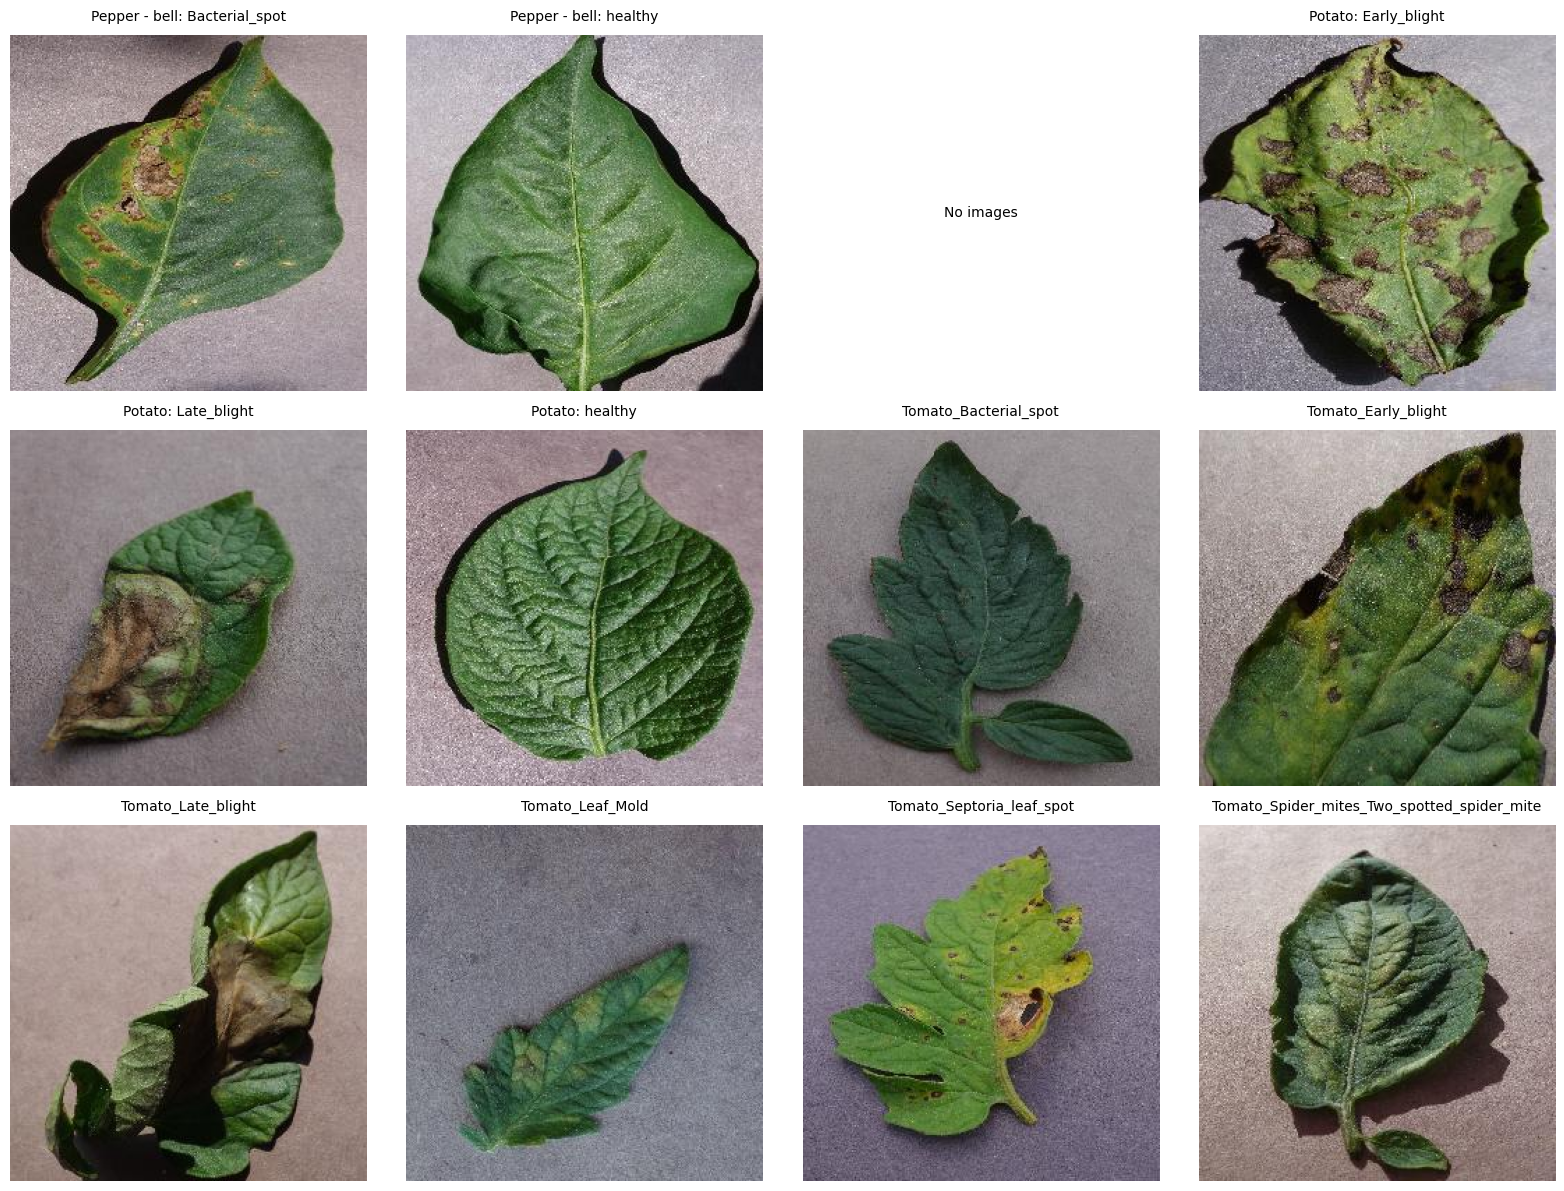


 Displaying sample images from 16 classes.


In [4]:
# Cell 3: Display sample images from different classes
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flat

for i, ax in enumerate(axes):
    if i < len(classes):
        # Get the class folder
        class_folder = dataset_path / classes[i]
        
        # Get all images in this folder
        image_files = list(class_folder.glob('*.jpg')) + list(class_folder.glob('*.JPG'))
        
        if image_files:
            # Load and display first image
            img_path = image_files[0]
            img = Image.open(img_path)
            
            ax.imshow(img)
            ax.set_title(classes[i].replace('___', ': ').replace('__', ' - '), 
                        fontsize=10, pad=10)
            ax.axis('off')
        else:
            ax.text(0.5, 0.5, 'No images', ha='center', va='center')
            ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\n Displaying sample images from {len(classes)} classes.")

In [5]:
# Cell 4: Count images per class
print("📊 Dataset Statistics\n")
print(f"{'Class Name':<35} {'Image Count':>12}")
print("-" * 50)

total_images = 0
for cls in classes:
    class_folder = dataset_path / cls
    image_count = len(list(class_folder.glob('*.jpg')) + list(class_folder.glob('*.JPG')))
    total_images += image_count
    print(f"{cls:<35} {image_count:>12}")

print("-" * 50)
print(f"{'TOTAL':<35} {total_images:>12}")
print(f"\n✅ You have {total_images:,} total training images!")

📊 Dataset Statistics

Class Name                           Image Count
--------------------------------------------------
Pepper__bell___Bacterial_spot               1994
Pepper__bell___healthy                      2954
PlantVillage                                   0
Potato___Early_blight                       2000
Potato___Late_blight                        2000
Potato___healthy                             304
Tomato_Bacterial_spot                       4254
Tomato_Early_blight                         2000
Tomato_Late_blight                          3816
Tomato_Leaf_Mold                            1904
Tomato_Septoria_leaf_spot                   3542
Tomato_Spider_mites_Two_spotted_spider_mite         3352
Tomato__Target_Spot                         2808
Tomato__Tomato_YellowLeaf__Curl_Virus         6416
Tomato__Tomato_mosaic_virus                  746
Tomato_healthy                              3182
--------------------------------------------------
TOTAL                            

In [6]:
# Cell 6: Split dataset into train/val/test
import os
import shutil
import random
from pathlib import Path

# Set random seed for reproducibility
random.seed(42)

# Source directory 
source_dir = Path("datasets/plantvillage/train/PlantVillage")

# Create output directory structure
output_dir = Path("datasets/plantvillage_yolo")
for split in ['train', 'val']:
    (output_dir / split).mkdir(parents=True, exist_ok=True)

# Split ratios: 80% train, 20% val
train_ratio = 0.80

print("Splitting dataset into train/val...\n")
print(f"{'Class Name':<40} {'Train':>8} {'Val':>8}")
print("-" * 60)

for class_name in classes:
    class_folder = source_dir / class_name
    
    # Get all images
    images = list(class_folder.glob('*.jpg')) + list(class_folder.glob('*.JPG'))
    
    # Shuffle images
    random.shuffle(images)
    
    # Calculate split point
    total = len(images)
    train_end = int(total * train_ratio)
    
    # Split into train and val
    train_imgs = images[:train_end]
    val_imgs = images[train_end:]
    
    # Create class folders in train and val
    for split in ['train', 'val']:
        (output_dir / split / class_name).mkdir(parents=True, exist_ok=True)
    
    # Copy images to train folder
    for img in train_imgs:
        shutil.copy(img, output_dir / 'train' / class_name / img.name)
    
    # Copy images to val folder
    for img in val_imgs:
        shutil.copy(img, output_dir / 'val' / class_name / img.name)
    
    print(f"{class_name:<40} {len(train_imgs):>8} {len(val_imgs):>8}")

print("-" * 60)
total_train = sum(len(list((output_dir / 'train' / cls).glob('*'))) for cls in classes)
total_val = sum(len(list((output_dir / 'val' / cls).glob('*'))) for cls in classes)
print(f"{'TOTAL':<40} {total_train:>8} {total_val:>8}")

print("\nDataset split complete!")
print(f"New dataset location: {output_dir.absolute()}")

Splitting dataset into train/val...

Class Name                                  Train      Val
------------------------------------------------------------
Pepper__bell___Bacterial_spot                1595      399
Pepper__bell___healthy                       2363      591
PlantVillage                                    0        0
Potato___Early_blight                        1600      400
Potato___Late_blight                         1600      400
Potato___healthy                              243       61
Tomato_Bacterial_spot                        3403      851
Tomato_Early_blight                          1600      400
Tomato_Late_blight                           3052      764
Tomato_Leaf_Mold                             1523      381
Tomato_Septoria_leaf_spot                    2833      709
Tomato_Spider_mites_Two_spotted_spider_mite     2681      671
Tomato__Target_Spot                          2246      562
Tomato__Tomato_YellowLeaf__Curl_Virus        5132     1284
Tomato__Tomato

In [8]:
# Cell 7: Verify the split
split_dir = Path("datasets/plantvillage_yolo")

print("Verifying dataset structure...\n")

for split in ['train', 'val']:
    split_path = split_dir / split
    class_folders = [d for d in split_path.iterdir() if d.is_dir()]
    total_images = sum(len(list(cf.glob('*'))) for cf in class_folders)
    
    print(f"{split.upper()}:")
    print(f"  Classes: {len(class_folders)}")
    print(f"  Total images: {total_images}")
    print()

print("Ready to train!")

Verifying dataset structure...

TRAIN:
  Classes: 16
  Total images: 19804

VAL:
  Classes: 16
  Total images: 7428

Ready to train!
